In [15]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/TELCO_CHURN_PROJECT

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/TELCO_CHURN_PROJECT


In [16]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [17]:
# =====================================================
# PATH CONFIG
# =====================================================
def get_project_root() -> Path:
    """
    File notebook nằm ở: project_root/notebooks/03_threshold_tuning.ipynb
    Khi chạy trên Colab, bạn có thể chỉnh PROJECT_ROOT thủ công nếu cần.
    """
    return Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()


PROJECT_ROOT = get_project_root()

DATA_FE_ROOT = PROJECT_ROOT / "data" / "feature_engineering"
HYPERPARAM_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "hyperparameter_tuning"
THRESHOLD_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "threshold_tuning"
THRESHOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_FE_ROOT:", DATA_FE_ROOT)
print("HYPERPARAM_OUTPUT_DIR:", HYPERPARAM_OUTPUT_DIR)
print("THRESHOLD_OUTPUT_DIR:", THRESHOLD_OUTPUT_DIR)

PROJECT_ROOT: /content/drive/MyDrive/TELCO_CHURN_PROJECT
DATA_FE_ROOT: /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering
HYPERPARAM_OUTPUT_DIR: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/hyperparameter_tuning
THRESHOLD_OUTPUT_DIR: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/threshold_tuning


In [18]:
# =====================================================
# DATASET CONFIG
# =====================================================
DATASET_CONFIG = {
    "logistic_regression": {
        "data_file": DATA_FE_ROOT / "logistic_regression" / "telco_churn_fe_logistic.csv",
        "hyperparam_file": HYPERPARAM_OUTPUT_DIR / "logistic_regression_tuning_result.json",
        "model_name": "logistic_regression"
    },
    "naive_bayes": {
        "data_file": DATA_FE_ROOT / "naive_bayes" / "telco_churn_fe_nb.csv",
        "hyperparam_file": HYPERPARAM_OUTPUT_DIR / "naive_bayes_tuning_result.json",
        "model_name": "gaussian_naive_bayes"
    },
    "decision_tree": {
        "data_file": DATA_FE_ROOT / "decision_tree" / "telco_churn_fe_tree.csv",
        "hyperparam_file": HYPERPARAM_OUTPUT_DIR / "decision_tree_tuning_result.json",
        "model_name": "decision_tree"
    },
    "random_forest": {
        "data_file": DATA_FE_ROOT / "random_forest" / "telco_churn_fe_rf.csv",
        "hyperparam_file": HYPERPARAM_OUTPUT_DIR / "random_forest_tuning_result.json",
        "model_name": "random_forest"
    }
}

for k, v in DATASET_CONFIG.items():
    print(f"{k}:")
    print(" - data_file      =", v["data_file"])
    print(" - hyperparam_file=", v["hyperparam_file"])

logistic_regression:
 - data_file      = /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering/logistic_regression/telco_churn_fe_logistic.csv
 - hyperparam_file= /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/hyperparameter_tuning/logistic_regression_tuning_result.json
naive_bayes:
 - data_file      = /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering/naive_bayes/telco_churn_fe_nb.csv
 - hyperparam_file= /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/hyperparameter_tuning/naive_bayes_tuning_result.json
decision_tree:
 - data_file      = /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering/decision_tree/telco_churn_fe_tree.csv
 - hyperparam_file= /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/hyperparameter_tuning/decision_tree_tuning_result.json
random_forest:
 - data_file      = /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering/random_forest/telco_churn_fe_rf.csv
 - hyperparam_file= /content/drive/MyDrive/TEL

In [19]:
# =====================================================
# LOAD DATA + FEATURE TYPE DETECTION
# =====================================================
def load_dataset(csv_path: Path):
    if not csv_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file dữ liệu: {csv_path}")

    df = pd.read_csv(csv_path)

    if "Churn" not in df.columns:
        raise ValueError(f"File {csv_path.name} không có cột 'Churn'")

    df = df.copy()
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

    if df["Churn"].isna().any():
        raise ValueError(f"Cột Churn trong {csv_path.name} có giá trị ngoài Yes/No")

    X = df.drop(columns=["Churn"])
    y = df["Churn"]

    return df, X, y


def detect_feature_types(X: pd.DataFrame):
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    return categorical_cols, numeric_cols

In [20]:
# =====================================================
# PREPROCESSOR BUILDERS
# =====================================================
def build_preprocessor_for_logistic(X: pd.DataFrame):
    categorical_cols, numeric_cols = detect_feature_types(X)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )
    return preprocessor


def build_preprocessor_for_nb(X: pd.DataFrame):
    categorical_cols, numeric_cols = detect_feature_types(X)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop",
        sparse_threshold=0
    )
    return preprocessor


def build_preprocessor_for_tree_rf(X: pd.DataFrame):
    categorical_cols, numeric_cols = detect_feature_types(X)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )
    return preprocessor

In [21]:
# =====================================================
# BUILD MODEL FROM BEST PARAMS
# =====================================================
def load_best_params(json_path: Path):
    if not json_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file hyperparameter result: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if "best_params" not in data:
        raise ValueError(f"File {json_path.name} không có khóa 'best_params'")

    return data["best_params"]


def strip_model_prefix(best_params: dict):
    cleaned = {}
    for k, v in best_params.items():
        if k.startswith("model__"):
            cleaned[k.replace("model__", "")] = v
        else:
            cleaned[k] = v
    return cleaned


def build_pipeline(algorithm_key: str, X_train: pd.DataFrame, best_params: dict):
    clean_params = strip_model_prefix(best_params)

    if algorithm_key == "logistic_regression":
        preprocessor = build_preprocessor_for_logistic(X_train)
        model = LogisticRegression(max_iter=3000, random_state=42, **clean_params)

    elif algorithm_key == "naive_bayes":
        preprocessor = build_preprocessor_for_nb(X_train)
        model = GaussianNB(**clean_params)

    elif algorithm_key == "decision_tree":
        preprocessor = build_preprocessor_for_tree_rf(X_train)
        model = DecisionTreeClassifier(random_state=42, **clean_params)

    elif algorithm_key == "random_forest":
        preprocessor = build_preprocessor_for_tree_rf(X_train)
        model = RandomForestClassifier(random_state=42, n_jobs=-1, **clean_params)

    else:
        raise ValueError(f"Thuật toán không hợp lệ: {algorithm_key}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

In [30]:
# =====================================================
# THRESHOLD EVALUATION
# =====================================================
from sklearn.metrics import fbeta_score

def evaluate_at_threshold(y_true, y_prob, threshold: float, beta=2):
    y_pred = (y_prob >= threshold).astype(int)

    result = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f_beta": float(fbeta_score(y_true, y_pred, beta=beta, zero_division=0)),
        "cm": confusion_matrix(y_true, y_pred).tolist(),
        "classification_report": classification_report(y_true, y_pred, zero_division=0)
    }
    return result


def find_best_threshold_constrained(
    y_true,
    y_prob,
    optimize_for="recall",
    threshold_list=None,
    min_precision=0.45,
    min_recall=0.0,
    min_threshold=0.10,
    beta=2
):
    """
    Tìm threshold tối ưu có ràng buộc:
    - precision >= min_precision
    - recall >= min_recall
    - threshold >= min_threshold

    optimize_for:
    - 'recall'
    - 'f1'
    - 'f_beta'
    - 'precision'
    - 'accuracy'
    """

    if threshold_list is None:
        threshold_list = np.arange(min_threshold, 1.00, 0.01)

    valid_metrics = ["recall", "f1", "f_beta", "precision", "accuracy"]
    if optimize_for not in valid_metrics:
        raise ValueError(f"optimize_for phải thuộc {valid_metrics}")

    all_results = []
    candidate_results = []

    for threshold in threshold_list:
        result = evaluate_at_threshold(y_true, y_prob, threshold, beta=beta)
        all_results.append(result)

        if (
            result["precision"] >= min_precision and
            result["recall"] >= min_recall and
            result["threshold"] >= min_threshold
        ):
            candidate_results.append(result)

    all_results_df = pd.DataFrame(all_results)

    if len(candidate_results) == 0:
        print("Không có threshold nào thỏa ràng buộc.")
        print("=> Sẽ fallback sang threshold có f_beta cao nhất trong toàn bộ khoảng quét.")
        best_result = all_results_df.sort_values(
            by=["f_beta", "recall", "precision"],
            ascending=[False, False, False]
        ).iloc[0].to_dict()
        return best_result, all_results_df

    candidate_df = pd.DataFrame(candidate_results)

    best_result = candidate_df.sort_values(
        by=[optimize_for, "recall", "precision"],
        ascending=[False, False, False]
    ).iloc[0].to_dict()

    return best_result, all_results_df

In [31]:
# =====================================================
# RUN ONE ALGORITHM
# =====================================================
def run_threshold_tuning_for_one_model(algorithm_key: str, optimize_for="f1"):
    config = DATASET_CONFIG[algorithm_key]

    data_file = config["data_file"]
    hyperparam_file = config["hyperparam_file"]
    model_name = config["model_name"]

    print("\n" + "=" * 100)
    print(f"RUNNING THRESHOLD TUNING: {algorithm_key}")
    print("DATA FILE       :", data_file)
    print("HYPERPARAM FILE :", hyperparam_file)
    print("OPTIMIZE FOR    :", optimize_for)

    # 1. load data
    df, X, y = load_dataset(data_file)

    # 2. split train/test giống file hyperparameter_tuning.py
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 3. load best params
    best_params = load_best_params(hyperparam_file)

    # 4. build pipeline
    pipeline = build_pipeline(algorithm_key, X_train, best_params)

    # 5. fit lại model với best params
    pipeline.fit(X_train, y_train)

    # 6. predict probability
    if not hasattr(pipeline, "predict_proba"):
        raise ValueError(f"Model {model_name} không hỗ trợ predict_proba")

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # 7. default threshold = 0.5
    default_result = evaluate_at_threshold(y_test, y_prob, threshold=0.5)

    # 8. threshold tuning
    best_result, threshold_df = find_best_threshold_constrained(
    y_true=y_test,
    y_prob=y_prob,
    optimize_for=optimize_for,
    min_precision=0.45,   # chỉnh được
    min_recall=0.0,
    min_threshold=0.10,   # không cho threshold xuống quá thấp
    beta=2
)

    # 9. save threshold table
    threshold_table_path = THRESHOLD_OUTPUT_DIR / f"{algorithm_key}_threshold_scan.csv"
    threshold_df.to_csv(threshold_table_path, index=False, encoding="utf-8-sig")

    # 10. save summary json
    summary = {
        "algorithm_key": algorithm_key,
        "model_name": model_name,
        "optimize_for": optimize_for,
        "best_params": best_params,
        "default_threshold_result": default_result,
        "optimized_threshold_result": best_result
    }

    summary_json_path = THRESHOLD_OUTPUT_DIR / f"{algorithm_key}_threshold_tuning_result.json"
    with open(summary_json_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4, ensure_ascii=False)

    print("\nDEFAULT (0.5):")
    print(default_result)

    print("\nOPTIMIZED:")
    print(best_result)

    print("\nSaved files:")
    print(" -", threshold_table_path)
    print(" -", summary_json_path)

    return {
        "algorithm_key": algorithm_key,
        "model_name": model_name,
        "optimize_for": optimize_for,
        "default_result": default_result,
        "optimized_result": best_result,
        "threshold_table_path": threshold_table_path,
        "summary_json_path": summary_json_path,
        "threshold_df": threshold_df
    }

In [32]:
# =====================================================
# RUN ALL MODELS
# =====================================================
OPTIMIZE_FOR = "f_beta"
min_precision = 0.45
min_threshold = 0.10
beta = 2
# Có thể đổi thành:
# "recall" nếu bạn muốn tối ưu bắt dương tính nhiều hơn
# "precision" nếu muốn giảm false positive
# "accuracy" nếu muốn tối ưu độ chính xác tổng thể

all_results = []

for algorithm_key in DATASET_CONFIG.keys():
    try:
        result = run_threshold_tuning_for_one_model(
            algorithm_key=algorithm_key,
            optimize_for=OPTIMIZE_FOR
        )

        all_results.append({
            "algorithm_key": result["algorithm_key"],
            "model_name": result["model_name"],

            "default_threshold": result["default_result"]["threshold"],
            "default_accuracy": result["default_result"]["accuracy"],
            "default_precision": result["default_result"]["precision"],
            "default_recall": result["default_result"]["recall"],
            "default_f1": result["default_result"]["f1"],

            "best_threshold": result["optimized_result"]["threshold"],
            "best_accuracy": result["optimized_result"]["accuracy"],
            "best_precision": result["optimized_result"]["precision"],
            "best_recall": result["optimized_result"]["recall"],
            "best_f1": result["optimized_result"]["f1"]
        })

    except Exception as e:
        print(f"\nLỗi khi chạy {algorithm_key}: {e}")

summary_df = pd.DataFrame(all_results)

summary_csv_path = THRESHOLD_OUTPUT_DIR / "threshold_tuning_summary.csv"
summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

print("\n" + "=" * 100)
print("THRESHOLD TUNING SUMMARY")
display(summary_df.sort_values(by="best_f1", ascending=False))
print("\nSaved summary:", summary_csv_path)


RUNNING THRESHOLD TUNING: logistic_regression
DATA FILE       : /content/drive/MyDrive/TELCO_CHURN_PROJECT/data/feature_engineering/logistic_regression/telco_churn_fe_logistic.csv
HYPERPARAM FILE : /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/hyperparameter_tuning/logistic_regression_tuning_result.json
OPTIMIZE FOR    : f_beta

DEFAULT (0.5):
{'threshold': 0.5, 'accuracy': 0.728500355366027, 'precision': 0.49331103678929766, 'recall': 0.7887700534759359, 'f1': 0.6069958847736625, 'f_beta': 0.7043935052531041, 'cm': [[730, 303], [79, 295]], 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.90      0.71      0.79      1033\n           1       0.49      0.79      0.61       374\n\n    accuracy                           0.73      1407\n   macro avg       0.70      0.75      0.70      1407\nweighted avg       0.79      0.73      0.74      1407\n'}

OPTIMIZED:
{'threshold': 0.3799999999999999, 'accuracy': 0.6830135039090263, 'preci

,algorithm_key,model_name,default_threshold,default_accuracy,default_precision,default_recall,default_f1,best_threshold,best_accuracy,best_precision,best_recall,best_f1
2,decision_tree,decision_tree,0.5,0.731343,0.496599,0.780749,0.607069,0.39,0.731343,0.496599,0.780749,0.607069
0,logistic_regression,logistic_regression,0.5,0.728500,0.493311,0.788770,0.606996,0.38,0.683014,0.451482,0.895722,0.600358
3,random_forest,random_forest,0.5,0.763326,0.539499,0.748663,0.627100,0.30,0.685856,0.452381,0.863636,0.593750
1,naive_bayes,gaussian_naive_bayes,0.5,0.704335,0.467290,0.802139,0.590551,0.12,0.692253,0.456296,0.823529,0.587226



Saved summary: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/threshold_tuning/threshold_tuning_summary.csv


In [33]:
# =====================================================
# IMPROVEMENT ANALYSIS
# =====================================================
if not summary_df.empty:
    analysis_df = summary_df.copy()
    analysis_df["f1_improvement"] = analysis_df["best_f1"] - analysis_df["default_f1"]
    analysis_df["recall_improvement"] = analysis_df["best_recall"] - analysis_df["default_recall"]
    analysis_df["precision_improvement"] = analysis_df["best_precision"] - analysis_df["default_precision"]
    analysis_df["accuracy_improvement"] = analysis_df["best_accuracy"] - analysis_df["default_accuracy"]

    analysis_csv_path = THRESHOLD_OUTPUT_DIR / "threshold_tuning_improvement_analysis.csv"
    analysis_df.to_csv(analysis_csv_path, index=False, encoding="utf-8-sig")

    display(
        analysis_df.sort_values(by="f1_improvement", ascending=False)
    )

    print("Saved:", analysis_csv_path)
else:
    print("Không có kết quả để phân tích.")

,algorithm_key,model_name,default_threshold,default_accuracy,default_precision,default_recall,default_f1,best_threshold,best_accuracy,best_precision,best_recall,best_f1,f1_improvement,recall_improvement,precision_improvement,accuracy_improvement
2,decision_tree,decision_tree,0.5,0.731343,0.496599,0.780749,0.607069,0.39,0.731343,0.496599,0.780749,0.607069,0.000000,0.000000,0.000000,0.000000
1,naive_bayes,gaussian_naive_bayes,0.5,0.704335,0.467290,0.802139,0.590551,0.12,0.692253,0.456296,0.823529,0.587226,-0.003325,0.021390,-0.010993,-0.012082
0,logistic_regression,logistic_regression,0.5,0.728500,0.493311,0.788770,0.606996,0.38,0.683014,0.451482,0.895722,0.600358,-0.006637,0.106952,-0.041829,-0.045487
3,random_forest,random_forest,0.5,0.763326,0.539499,0.748663,0.627100,0.30,0.685856,0.452381,0.863636,0.593750,-0.033350,0.114973,-0.087118,-0.077470


Saved: /content/drive/MyDrive/TELCO_CHURN_PROJECT/outputs/threshold_tuning/threshold_tuning_improvement_analysis.csv


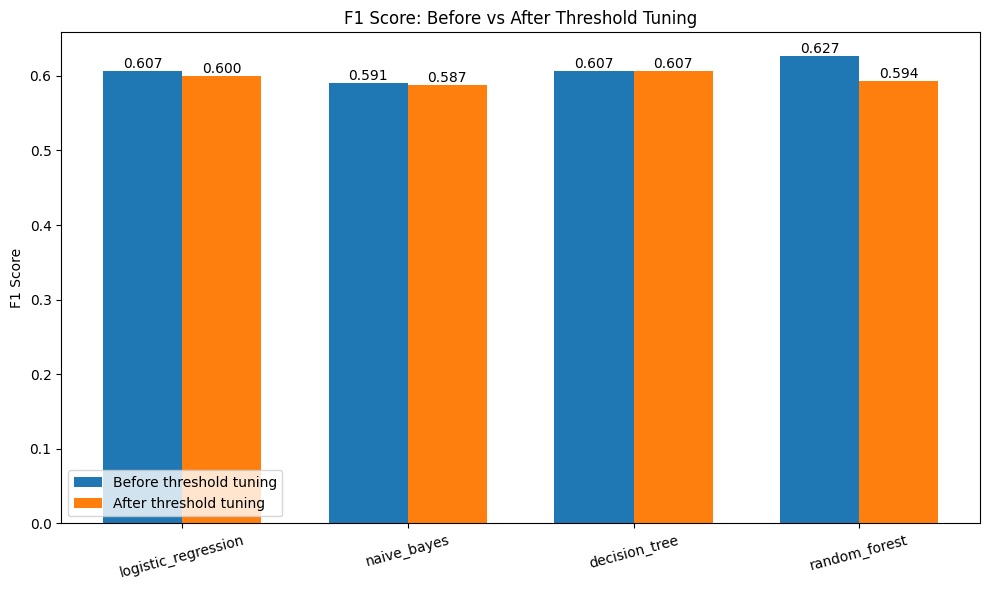

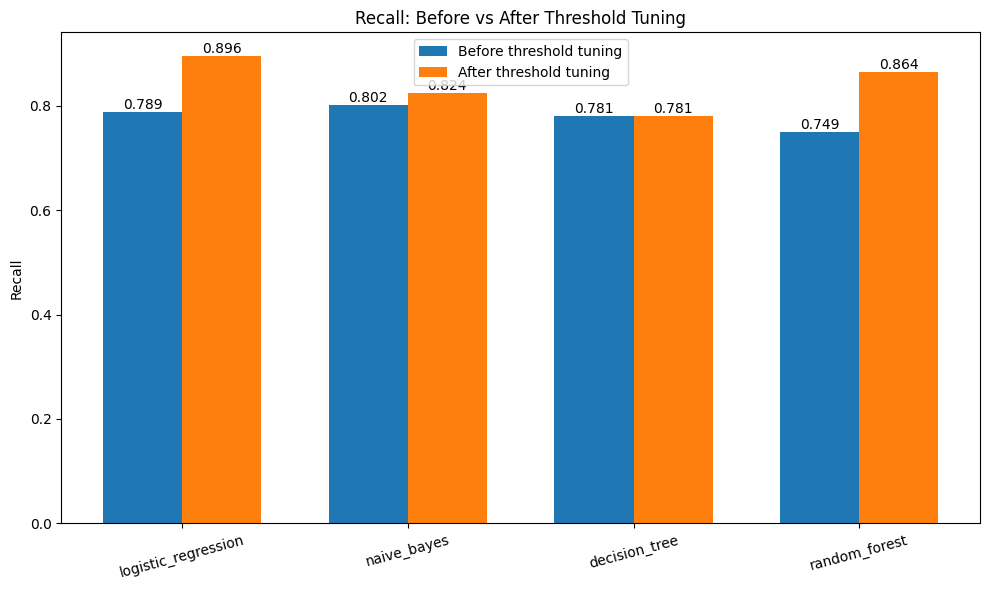

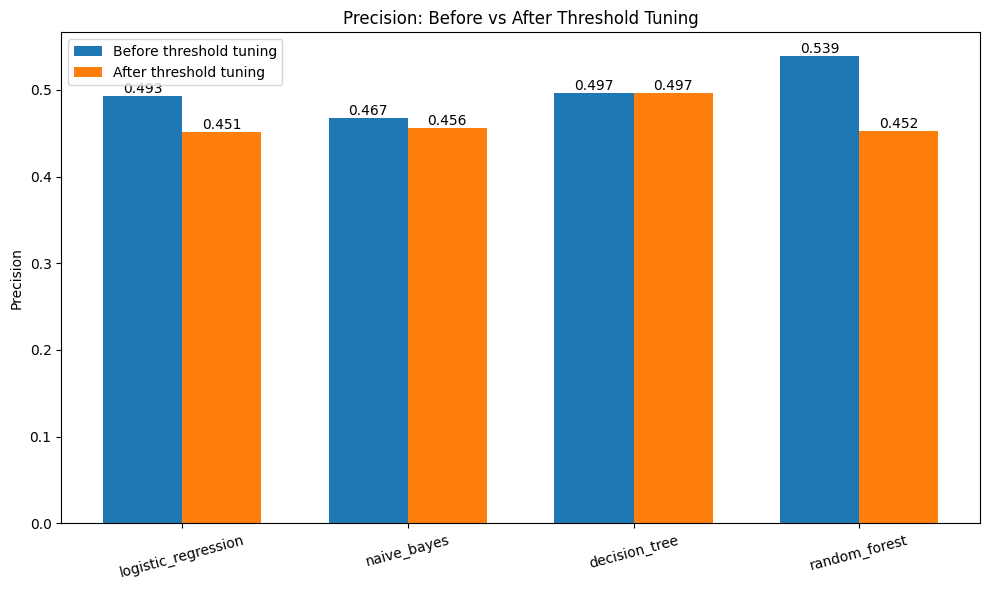

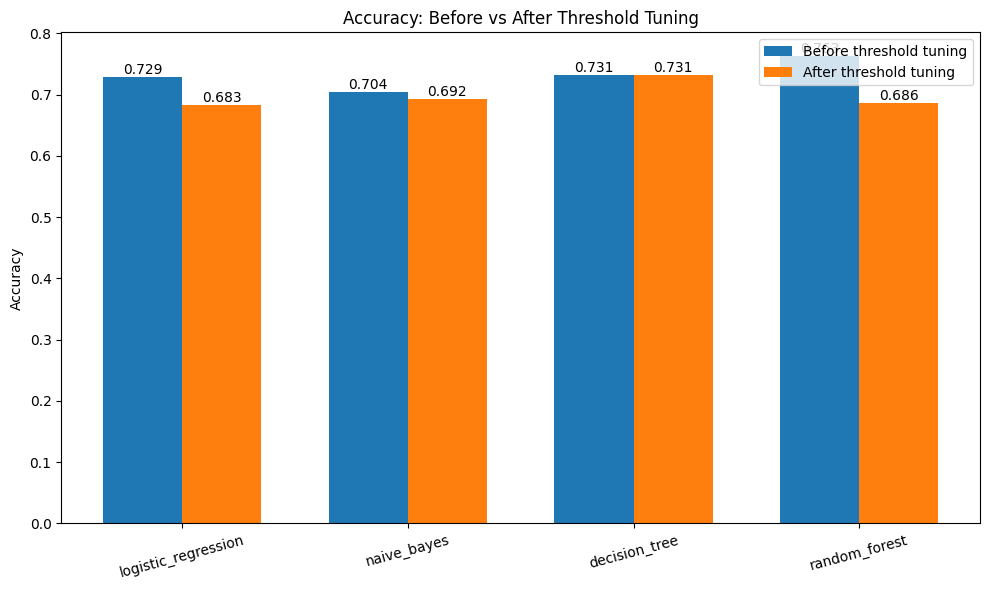

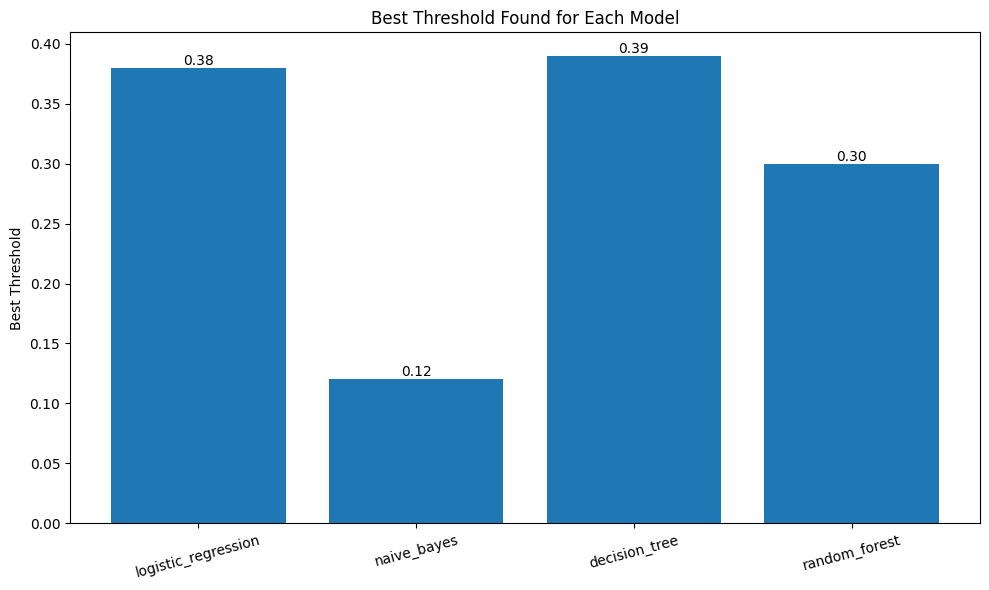

In [34]:
# =====================================================
# VISUALIZATION WITH VALUE LABELS
# =====================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_before_after_bar(df, before_col, after_col, ylabel, title):
    model_names = df["algorithm_key"].tolist()
    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, df[before_col], width, label="Before threshold tuning")
    bars2 = ax.bar(x + width/2, df[after_col], width, label="After threshold tuning")

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

    for bar in bars1:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

    for bar in bars2:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


if summary_df.empty:
    print("Chưa có dữ liệu trong summary_df. Hãy chạy CELL 9 trước.")
else:
    plot_before_after_bar(
        summary_df,
        "default_f1",
        "best_f1",
        "F1 Score",
        "F1 Score: Before vs After Threshold Tuning"
    )

    plot_before_after_bar(
        summary_df,
        "default_recall",
        "best_recall",
        "Recall",
        "Recall: Before vs After Threshold Tuning"
    )

    plot_before_after_bar(
        summary_df,
        "default_precision",
        "best_precision",
        "Precision",
        "Precision: Before vs After Threshold Tuning"
    )

    plot_before_after_bar(
        summary_df,
        "default_accuracy",
        "best_accuracy",
        "Accuracy",
        "Accuracy: Before vs After Threshold Tuning"
    )

    # Best threshold
    model_names = summary_df["algorithm_key"].tolist()
    x = np.arange(len(model_names))

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(x, summary_df["best_threshold"])

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15)
    ax.set_ylabel("Best Threshold")
    ax.set_title("Best Threshold Found for Each Model")

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

In [35]:
# =====================================================
# CHECK ONE MODEL DETAIL
# =====================================================
MODEL_TO_VIEW = "logistic_regression"  # đổi nếu muốn

detail_path = THRESHOLD_OUTPUT_DIR / f"{MODEL_TO_VIEW}_threshold_tuning_result.json"

if detail_path.exists():
    with open(detail_path, "r", encoding="utf-8") as f:
        detail = json.load(f)

    print(json.dumps(detail, indent=4, ensure_ascii=False))
else:
    print("Không tìm thấy file:", detail_path)

{
    "algorithm_key": "logistic_regression",
    "model_name": "logistic_regression",
    "optimize_for": "f_beta",
    "best_params": {
        "model__C": 50,
        "model__class_weight": "balanced",
        "model__penalty": "l1",
        "model__solver": "liblinear"
    },
    "default_threshold_result": {
        "threshold": 0.5,
        "accuracy": 0.728500355366027,
        "precision": 0.49331103678929766,
        "recall": 0.7887700534759359,
        "f1": 0.6069958847736625,
        "f_beta": 0.7043935052531041,
        "cm": [
            [
                730,
                303
            ],
            [
                79,
                295
            ]
        ],
        "classification_report": "              precision    recall  f1-score   support\n\n           0       0.90      0.71      0.79      1033\n           1       0.49      0.79      0.61       374\n\n    accuracy                           0.73      1407\n   macro avg       0.70      0.75      0.70  

In [36]:
# =====================================================
# TOP THRESHOLDS FOR ONE MODEL
# =====================================================
MODEL_TO_VIEW = "logistic_regression"  # đổi nếu muốn
SORT_BY = "f1"                         # có thể đổi: recall, precision, accuracy

scan_path = THRESHOLD_OUTPUT_DIR / f"{MODEL_TO_VIEW}_threshold_scan.csv"

if scan_path.exists():
    scan_df = pd.read_csv(scan_path)
    display(scan_df.sort_values(by=SORT_BY, ascending=False).head(10))
else:
    print("Không tìm thấy file:", scan_path)

,threshold,accuracy,precision,recall,f1,f_beta,cm,classification_report
51,0.61,0.784648,0.578366,0.700535,0.633615,0.672140,"[[842, 191], [112, 262]]",precision recall f1-score ...
50,0.60,0.779673,0.568376,0.711230,0.631829,0.677189,"[[831, 202], [108, 266]]",precision recall f1-score ...
52,0.62,0.785359,0.581448,0.687166,0.629902,0.663055,"[[848, 185], [117, 257]]",precision recall f1-score ...
49,0.59,0.773987,0.558091,0.719251,0.628505,0.679980,"[[820, 213], [105, 269]]",precision recall f1-score ...
53,0.63,0.784648,0.581986,0.673797,0.624535,0.653188,"[[852, 181], [122, 252]]",precision recall f1-score ...
47,0.57,0.764037,0.541176,0.737968,0.624434,0.687936,"[[799, 234], [98, 276]]",precision recall f1-score ...
54,0.64,0.786070,0.585480,0.668449,0.624220,0.650026,"[[856, 177], [124, 250]]",precision recall f1-score ...
48,0.58,0.768301,0.548780,0.721925,0.623557,0.679074,"[[811, 222], [104, 270]]",precision recall f1-score ...
45,0.55,0.756930,0.530075,0.754011,0.622517,0.695266,"[[783, 250], [92, 282]]",precision recall f1-score ...
46,0.56,0.759773,0.534749,0.740642,0.621076,0.687686,"[[792, 241], [97, 277]]",precision recall f1-score ...
